# IPCA – Subgrupos (IBGE/SIDRA 7060)

Este notebook apresenta:

**1. O que são os subgrupos do IPCA**  
**2. Como o IBGE organiza a tabela 7060**  
**3. Execução do pipeline `ipca_subgrupos`**  
**4. Consulta ao banco de dados (`bcb.ipca_subgrupos`)**  
**5. Gráficos e análises exploratórias por subgrupo**  

Vamos começar entendendo o conceito.

# 1. O que são os subgrupos do IPCA?

O **IPCA (Índice Nacional de Preços ao Consumidor Amplo)** é estruturado em:

- grupos  
- **subgrupos (nível 5)**  
- itens  
- subitens  

Os **subgrupos** representam categorias intermediárias dentro dos grupos, como:

- Carnes  
- Leite e derivados  
- Tubérculos, raízes e legumes  
- Energia elétrica  

Trabalhar com subgrupos permite:

- análises setoriais mais amplas  
- decomposição da inflação por blocos de produtos  
- identificação de pressões inflacionárias por categoria

# 2. Tabela 7060 – IPCA por subgrupos

A tabela 7060 do SIDRA traz o IPCA por:

- Brasil (nível nacional)  
- grupos, subgrupos, itens e subitens  

As variáveis que usamos aqui são:

- **63** → variação mensal (%), chamada `indice`  
- **66** → peso do subgrupo no índice, chamada `peso`  

Nosso pipeline monta a tabela `bcb.ipca_subgrupos` com:

- `date`  
- `indice`  
- `peso`  
- `category` (código numérico de 5 dígitos)  
- `category_name` (descrição do subgrupo)

# 3. Ajustar o PYTHONPATH para importar `src/`

In [24]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)
print("PYTHONPATH atualizado:", ROOT)

PYTHONPATH atualizado: /home/moacir/projects/ml/analytics/inflation


# 4. Importações

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipelines.ipca_subgrupos import run_ipca_subgrupos
from src.database.connection import engine

pd.set_option("display.float_format", "{:.6f}".format)

# 5. Executar pipeline IPCA subgrupos (IBGE – tabela 7060)

Isso irá:
- consultar a tabela 7060 do SIDRA  
- baixar as variáveis 63 (Indice) e 66 (Peso)  
- filtrar apenas subgrupos (nível 5)  
- criar/atualizar a tabela `bcb.ipca_subgrupos`  
- inserir todos os dados no PostgreSQL

In [26]:
run_ipca_subgrupos()

2026-04-20 20:32:09,288 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=7060, variavel=63, periodo=all
2026-04-20 20:32:11,120 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.
2026-04-20 20:32:11,140 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=7060, variavel=66, periodo=all
2026-04-20 20:32:15,053 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.


Tabela bcb.ipca_subgrupos atualizada com sucesso!


,date,indice,peso,category,category_name
0,2020-01-01,0.200000,13.481300,11,Alimentação no domicílio
1,2020-01-01,0.820000,5.867000,12,Alimentação fora do domicílio
2,2020-01-01,0.680000,9.980800,21,Encargos e manutenção
3,2020-01-01,0.310000,5.613800,22,Combustíveis e energia
4,2020-01-01,-0.190000,1.794900,31,Móveis e utensílios
...,...,...,...,...,...
1420,2026-03-01,0.400000,4.001700,63,Cuidados pessoais
1421,2026-03-01,0.740000,6.331700,71,Serviços pessoais
1422,2026-03-01,0.500000,3.957400,72,Recreação e fumo
1423,2026-03-01,0.020000,6.303500,81,"Cursos, leitura e papelaria"


# 6. Verificar tabelas existentes no schema `bcb`

In [27]:
pd.read_sql("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'bcb'
ORDER BY table_name;
""", engine)

,table_name
0,ipca
1,ipca_itens
2,ipca_subgrupos
3,ipca_subitens
4,selic_meta
5,selic_over


# 7. Carregar dados de IPCA subgrupos

In [30]:
query_subgrupos = """
select *
from bcb.ipca_subgrupos
order by date desc, category;
"""

df = pd.read_sql(query_subgrupos, engine)
df.head(30)

,date,indice,peso,category,category_name
0,2026-03-01,1.940000,15.225200,11,Alimentação no domicílio
1,2026-03-01,0.610000,6.084200,12,Alimentação fora do domicílio
2,2026-03-01,0.320000,9.889300,21,Encargos e manutenção
3,2026-03-01,0.050000,5.409700,22,Combustíveis e energia
4,2026-03-01,0.210000,1.742600,31,Móveis e utensílios
5,2026-03-01,0.730000,1.389500,32,Aparelhos eletroeletrônicos
6,2026-03-01,1.110000,0.346800,33,Consertos e manutenção
7,2026-03-01,0.410000,3.104800,41,Roupas
8,2026-03-01,0.300000,1.220600,42,Calçados e acessórios
9,2026-03-01,1.840000,0.277400,43,Joias e bijuterias


# 8. Primeiros registros

In [31]:
df.tail(10)

,date,indice,peso,category,category_name
1415,2020-01-01,0.690000,0.199600,43,Joias e bijuterias
1416,2020-01-01,-0.180000,0.055100,44,Tecidos e armarinho
1417,2020-01-01,0.320000,20.597900,51,Transportes
1418,2020-01-01,0.250000,3.789800,61,Produtos farmacêuticos e óticos
1419,2020-01-01,0.500000,5.804100,62,Serviços de saúde
1420,2020-01-01,-2.070000,3.939500,63,Cuidados pessoais
1421,2020-01-01,0.240000,6.787300,71,Serviços pessoais
1422,2020-01-01,0.530000,3.945700,72,Recreação e fumo
1423,2020-01-01,0.160000,6.148500,81,"Cursos, leitura e papelaria"
1424,2020-01-01,0.120000,5.714600,91,Comunicação


# 9. Estatísticas básicas

In [32]:
df.describe()

,date,indice,peso
count,1425,1425.000000,1425.000000
mean,2023-01-30 22:43:12,0.470660,5.263159
min,2020-01-01 00:00:00,-10.260000,0.051800
25%,2021-07-01 00:00:00,0.070000,1.737300
50%,2023-02-01 00:00:00,0.400000,3.969500
75%,2024-09-01 00:00:00,0.790000,5.987600
max,2026-03-01 00:00:00,11.790000,22.307100
std,NaN,1.066009,5.086169


# 10. Subgrupos com maior peso médio

Aqui vemos quais subgrupos têm maior relevância estrutural no IPCA.

In [33]:
top_peso = (
    df.groupby(["category", "category_name"])["peso"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

top_peso

,category,category_name,peso
0,51,Transportes,20.657075
1,11,Alimentação no domicílio,15.275592
2,21,Encargos e manutenção,9.809708
3,71,Serviços pessoais,6.333281
4,81,"Cursos, leitura e papelaria",5.952411
5,12,Alimentação fora do domicílio,5.875701
6,62,Serviços de saúde,5.651451
7,22,Combustíveis e energia,5.617005
8,91,Comunicação,5.075415
9,63,Cuidados pessoais,3.929148


# 11. Evolução da variação mensal de um subgrupo específico

Vamos escolher um subgrupo de interesse (por exemplo, carnes) e analisar sua trajetória.

In [39]:
filtro = "im"

sub = df[df["category_name"].str.contains(filtro, case=False, na=False)]

sub.head()

,date,indice,peso,category,category_name
0,2026-03-01,1.940000,15.225200,11,Alimentação no domicílio
1,2026-03-01,0.610000,6.084200,12,Alimentação fora do domicílio
19,2026-02-01,0.230000,15.294700,11,Alimentação no domicílio
20,2026-02-01,0.340000,6.106800,12,Alimentação fora do domicílio
38,2026-01-01,0.100000,15.329100,11,Alimentação no domicílio


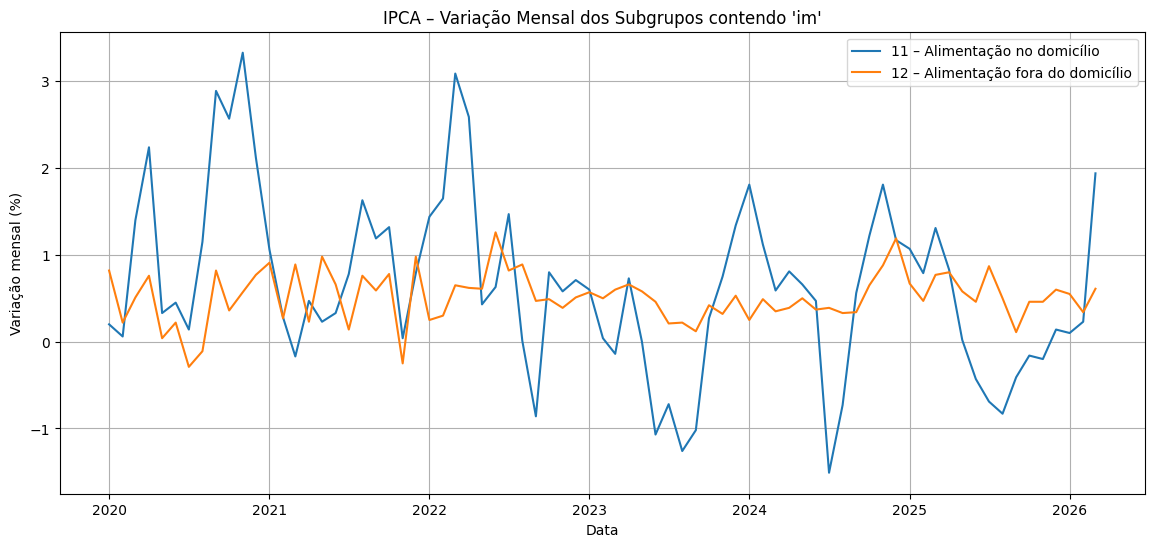

In [40]:
plt.figure(figsize=(14, 6))
for cat, g in sub.groupby("category"):
    plt.plot(g["date"], g["indice"], label=f"{cat} – {g['category_name'].iloc[0]}")

plt.title(f"IPCA – Variação Mensal dos Subgrupos contendo '{filtro}'")
plt.xlabel("Data")
plt.ylabel("Variação mensal (%)")
plt.grid(True)
plt.legend()
plt.show()

# 12. Heatmap de variação mensal – últimos 12 meses

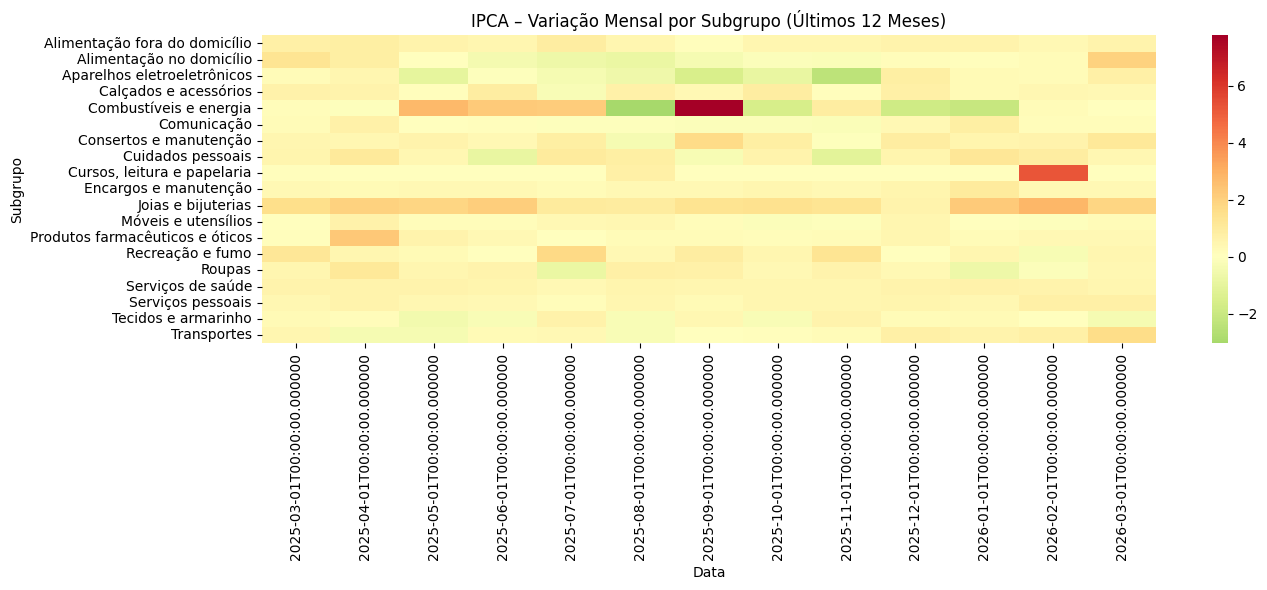

In [41]:
df_recent = df[df["date"] >= df["date"].max() - pd.offsets.DateOffset(months=12)]

pivot_hm = df_recent.pivot_table(
    index="category_name",
    columns="date",
    values="indice"
)

plt.figure(figsize=(14, max(6, len(pivot_hm) * 0.25)))
sns.heatmap(
    pivot_hm,
    cmap="RdYlGn_r",
    center=0,
    annot=False
)
plt.title("IPCA – Variação Mensal por Subgrupo (Últimos 12 Meses)")
plt.xlabel("Data")
plt.ylabel("Subgrupo")
plt.tight_layout()
plt.show()

# 13. Distribuição da variação mensal por subgrupo

Aqui avaliamos a dispersão da inflação entre subgrupos em um mês recente.

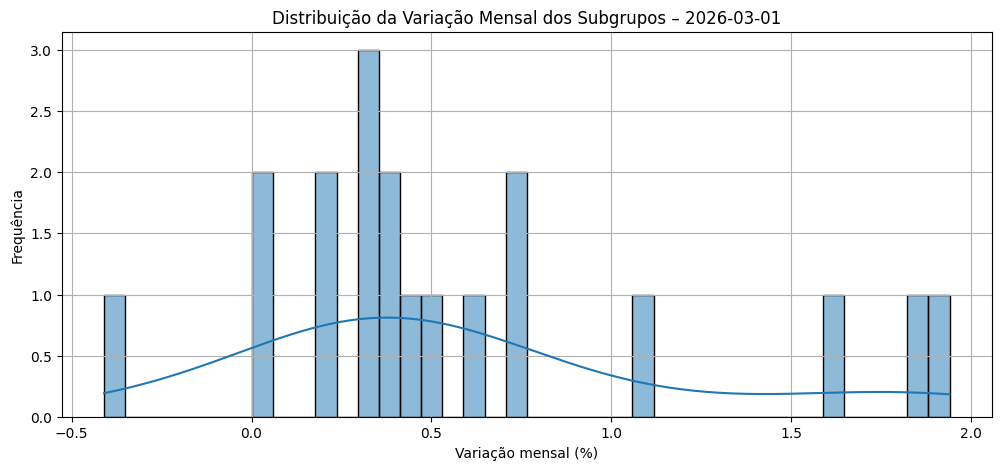

In [42]:
ultimo_mes = df["date"].max()
df_ult = df[df["date"] == ultimo_mes]

plt.figure(figsize=(12, 5))
sns.histplot(df_ult["indice"], bins=40, kde=True)
plt.title(f"Distribuição da Variação Mensal dos Subgrupos – {ultimo_mes.date()}")
plt.xlabel("Variação mensal (%)")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

# 14. Conclusões

- A tabela `bcb.ipca_subgrupos` traz o IPCA no nível intermediário (subgrupos).  
- As colunas `indice` e `peso` permitem análises de contribuição e relevância de cada subgrupo.  
- A estrutura `category` (código) + `category_name` (descrição) facilita junções e painéis.  
- Este pipeline é a base para:
  - decomposição da inflação por grupo e subgrupo  
  - análises setoriais  
  - construção de núcleos e medidas alternativas  

Próximos passos:
- Integrar esta tabela com o IPCA geral (`bcb.ipca`)  
- Construir decomposições por grupo, subgrupo e item  
- Criar dashboards e relatórios automatizados de inflação por subgrupo